# ASL Fingerspelling v6 — Fine-tune v5 + Supplemental Data

Loads the **v5 Conformer-Transformer checkpoint** and fine-tunes it on:
- **~67 K** NPY sequences from the main competition split (same 70/15/15 as v5)
- **~50 K** supplemental fingerspelling sequences loaded from raw parquet (RAM-cached)

Key changes over v5:
| Feature | v5 | v6 (this notebook) |
|---|---|---|
| Training data | 48 K NPY only | 48 K NPY + 50 K supplemental |
| Scheduled sampling start | epoch 8 | epoch 8 |
| Checkpoint | `asl_transformer_v5_best.pth` | `asl_transformer_v6_best.pth` |
| Resume token | `RESUME_FROM = CKPT_LAST` | same |


## 1. Setup & Configuration

In [1]:
import os, math, json, time, random, warnings, subprocess, sys
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.amp import GradScaler, autocast

try:
    import editdistance
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'editdistance'])
    import editdistance

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU  {torch.cuda.get_device_name(0)}')
print(f'VRAM {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

GPU  Tesla T4
VRAM 15.6 GB


## 2. Paths & Hyperparameters

In [ ]:
class Config:
    #Competition Data (Attached standard ASL fingerspelling dataset)
    COMP_DIR    = Path('/kaggle/input/competitions/asl-fingerspelling')
    TRAIN_META  = COMP_DIR / 'train.csv'
    SUPP_META   = COMP_DIR / 'supplemental_metadata.csv'
    CHARMAP     = COMP_DIR / 'character_to_prediction_index.json'

    #v5 Starting Checkpoint
    CKPT_V5     = Path('/kaggle/input/models/tarunjoseph98/asl-transformer-v5-best/pytorch/default/1/asl_transformer_v5_best_progress update.pth')

    #Outputs & Processed NPY Directories
    OUTPUT_DIR  = Path('/kaggle/working')
    NPY_TRAIN   = OUTPUT_DIR / 'npy_train'
    NPY_SUPP    = OUTPUT_DIR / 'npy_supp'
    
    CKPT_BEST   = OUTPUT_DIR / 'asl_transformer_v6_best.pth'
    CKPT_LAST   = OUTPUT_DIR / 'asl_transformer_v6_last.pth'

    #Data & Model Dimensions
    FEATURE_SIZE   = 84     
    MAX_SEQ_LEN    = 64
    MAX_PHRASE_LEN = 34     
    D_MODEL    = 384
    ENC_LAYERS = 6
    DEC_LAYERS = 6
    N_HEADS    = 6
    FFN_DIM    = 1024
    EMBED_DIM  = 192
    DROPOUT    = 0.25

    # Training
    BATCH_SIZE     = 96
    EPOCHS         = 30
    LR             = 5e-5       
    WEIGHT_DECAY   = 1e-4
    WARMUP_EPOCHS  = 2
    LABEL_SMOOTH   = 0.20
    GRAD_CLIP      = 1.0
    NUM_WORKERS    = 2
    PATIENCE       = 10

    # Scheduled Sampling
    SS_START_EPOCH   = 8
    SS_EPSILON_START = 1.0   
    SS_EPSILON_END   = 0.3   

    # Inference
    BEAM_WIDTH      = 5
    LENGTH_PENALTY  = 0.6
    RESUME_FROM     = None

# Create working directories
Config.NPY_TRAIN.mkdir(parents=True, exist_ok=True)
Config.NPY_SUPP.mkdir(parents=True, exist_ok=True)

for p, tag in [(Config.TRAIN_META, 'TRAIN_META'), (Config.CHARMAP, 'CHARMAP'), 
               (Config.SUPP_META, 'SUPP_META'), (Config.CKPT_V5, 'CKPT_V5')]:
    print(f"{'YES' if p.exists() else 'NO MISSING':<10} {tag}")

✓          TRAIN_META
✓          CHARMAP
✓          SUPP_META
✓          CKPT_V5


## 3. Vocabulary Definition

In [3]:
with open(Config.CHARMAP) as f:
    char_to_idx = json.load(f)

idx_to_char  = {v: k for k, v in char_to_idx.items()}
N_CLASSES    = len(char_to_idx)         # 59
START_IDX    = N_CLASSES                # 59
EOS_IDX      = N_CLASSES + 1            # 60
PAD_IDX      = N_CLASSES + 2            # 61
VOCAB_SIZE   = N_CLASSES + 3            # 62

print(f'Real chars {N_CLASSES}  START={START_IDX}  EOS={EOS_IDX}  PAD={PAD_IDX}  VOCAB={VOCAB_SIZE}')

Real chars 59  START=59  EOS=60  PAD=61  VOCAB=62


## 4. Parquet to NPY Processing Logic (with Fixed Normalization)

In [ ]:
# added .any(axis=1, keepdims=True) back so we mask whole hands, not individual coordinates
def wrist_normalize(seq: np.ndarray) -> np.ndarray:
    out = seq.copy()
    for offset in [0, 42]:
        lx = out[:, offset:offset+21]
        ly = out[:, offset+21:offset+42]
        wx, wy = lx[:, 0:1], ly[:, 0:1]
        
        visible = (lx != 0).any(axis=1, keepdims=True)  
        
        lx = np.where(visible, lx - wx, 0.0)
        ly = np.where(visible, ly - wy, 0.0)
        span = max(float(np.abs(lx).max()), float(np.abs(ly).max()), 1e-6)
        out[:, offset:offset+21]  = lx / span
        out[:, offset+21:offset+42] = ly / span
    return out.astype(np.float32)

_LH_X = [f'x_left_hand_{i}'  for i in range(21)]
_LH_Y = [f'y_left_hand_{i}'  for i in range(21)]
_RH_X = [f'x_right_hand_{i}' for i in range(21)]
_RH_Y = [f'y_right_hand_{i}' for i in range(21)]
_LOAD_COLS = ['frame'] + _LH_X + _LH_Y + _RH_X + _RH_Y

def process_parquets_to_npy(meta_df, base_dir, out_dir):
    for file_id, group in tqdm(meta_df.groupby('file_id'), desc=f"Processing to {out_dir.name}"):
        path = base_dir / f"{file_id}.parquet"
        if not path.exists(): continue
            
        dfp = pd.read_parquet(path, columns=_LOAD_COLS)
        seq_groups = dfp.groupby(dfp.index) 
        
        for seq_id in group['sequence_id']:
            if seq_id not in seq_groups.groups: continue
                
            rows = seq_groups.get_group(seq_id).sort_values('frame')
            n = len(rows)
            seq = np.zeros((n, 84), dtype=np.float32)
            seq[:, 0:21]  = rows[_LH_X].values.astype(np.float32)
            seq[:, 21:42] = rows[_LH_Y].values.astype(np.float32)
            seq[:, 42:63] = rows[_RH_X].values.astype(np.float32)
            seq[:, 63:84] = rows[_RH_Y].values.astype(np.float32)
            seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
            
            seq = wrist_normalize(seq)
            np.save(out_dir / f"{seq_id}.npy", seq)

train_meta = pd.read_csv(Config.TRAIN_META)
supp_meta  = pd.read_csv(Config.SUPP_META)

print(f'Train sequences: {len(train_meta):,} | Supplemental sequences: {len(supp_meta):,}')
process_parquets_to_npy(train_meta, Config.COMP_DIR / 'train_landmarks', Config.NPY_TRAIN)
process_parquets_to_npy(supp_meta, Config.COMP_DIR / 'supplemental_landmarks', Config.NPY_SUPP)

Train sequences: 67,208 | Supplemental sequences: 52,958


Processing to npy_train:   0%|          | 0/68 [00:00<?, ?it/s]

Processing to npy_supp:   0%|          | 0/53 [00:00<?, ?it/s]

## 5. Participant-Stratified Split (Main Data Only)

In [6]:
participants = train_meta['participant_id'].unique()
np.random.shuffle(participants)
n = len(participants)
tr_p  = set(participants[:int(n * 0.70)])
val_p = set(participants[int(n * 0.70):int(n * 0.85)])
te_p  = set(participants[int(n * 0.85):])

train_split_meta = train_meta[train_meta['participant_id'].isin(tr_p)].reset_index(drop=True)
val_split_meta   = train_meta[train_meta['participant_id'].isin(val_p)].reset_index(drop=True)
test_split_meta  = train_meta[train_meta['participant_id'].isin(te_p)].reset_index(drop=True)

print(f'Main Train: {len(train_split_meta):,} | Val: {len(val_split_meta):,} | Test: {len(test_split_meta):,}')

Main Train: 48,315 | Val: 8,749 | Test: 10,144


## 6. Augmentation & Datasets

In [ ]:
def _augment(seq: np.ndarray) -> np.ndarray:
    n = len(seq)
    
    # 1. Random Frame Dropout
    if random.random() < 0.5 and n > 8:                  
        keep = sorted(random.sample(range(n), int(n * 0.9)))
        seq  = seq[keep]
        n = len(seq) # Update n so the new length is tracked
        
    # 2. Additive Gaussian Noise
    if random.random() < 0.5:                              
        seq += np.random.normal(0, 0.01, seq.shape).astype(np.float32)
        
    # 3. Spatial Flip (Left/Right Hand swap)
    if random.random() < 0.5:                              
        seq = np.concatenate([seq[:, 42:84], seq[:, 0:42]], axis=1)
        seq[:, 0:21]  = -seq[:, 0:21]
        seq[:, 42:63] = -seq[:, 42:63]
        
    # 4. Time Warping (Interpolation)
    if random.random() < 0.4:                              
        T_new = max(4, int(n * random.uniform(0.8, 1.2)))
        seq   = seq[np.linspace(0, n-1, T_new, dtype=int)]
        
    return seq

def encode_phrase(phrase: str) -> list:
    chars = [char_to_idx.get(c, PAD_IDX) for c in phrase[:Config.MAX_PHRASE_LEN - 2]]
    seq   = [START_IDX] + chars + [EOS_IDX]
    seq  += [PAD_IDX] * (Config.MAX_PHRASE_LEN - len(seq))
    return seq[:Config.MAX_PHRASE_LEN]

class ProcessedNPYDataset(Dataset):
    def __init__(self, df, npy_dir, augment=False):
        self.df = df.reset_index(drop=True)
        self.npy_dir = npy_dir
        self.augment = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = self.npy_dir / f"{row['sequence_id']}.npy"
        
        if path.exists():
            seq = np.load(path).astype(np.float32)
        else:
            seq = np.zeros((Config.MAX_SEQ_LEN, 84), dtype=np.float32)
            
        if self.augment:
            seq = _augment(seq)

        T = len(seq)
        if T > Config.MAX_SEQ_LEN:
            seq = seq[np.linspace(0, T-1, Config.MAX_SEQ_LEN, dtype=int)]
        elif T < Config.MAX_SEQ_LEN:
            seq = np.vstack([seq, np.zeros((Config.MAX_SEQ_LEN - T, 84), dtype=np.float32)])

        x = torch.from_numpy(seq.T).float()
        y = torch.tensor(encode_phrase(str(row['phrase'])), dtype=torch.long)
        return x, y

ds_main_train = ProcessedNPYDataset(train_split_meta, Config.NPY_TRAIN, augment=True)
ds_supp_train = ProcessedNPYDataset(supp_meta, Config.NPY_SUPP, augment=True)
combined_train_ds = ConcatDataset([ds_main_train, ds_supp_train])
val_ds  = ProcessedNPYDataset(val_split_meta, Config.NPY_TRAIN, augment=False)

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=Config.BATCH_SIZE, shuffle=shuffle,
                      num_workers=Config.NUM_WORKERS, pin_memory=True,
                      persistent_workers=Config.NUM_WORKERS > 0)

train_loader = make_loader(combined_train_ds, shuffle=True)
val_loader   = make_loader(val_ds, shuffle=False)

## 7. Conformer-Transformer Model Definition

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, maxlen=512, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(maxlen, d_model)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])

class ConformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, kernel_size=31, dropout=0.1):
        super().__init__()
        self.ff1       = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, ffn_dim), nn.SiLU(), nn.Dropout(dropout), nn.Linear(ffn_dim, d_model), nn.Dropout(dropout))
        self.norm_attn = nn.LayerNorm(d_model)
        self.attn      = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.drop_attn = nn.Dropout(dropout)
        self.norm_conv = nn.LayerNorm(d_model)
        self.conv      = nn.Sequential(nn.Conv1d(d_model, 2*d_model, 1), nn.GLU(dim=1), nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2, groups=d_model), nn.BatchNorm1d(d_model), nn.SiLU(), nn.Conv1d(d_model, d_model, 1), nn.Dropout(dropout))
        self.ff2      = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, ffn_dim), nn.SiLU(), nn.Dropout(dropout), nn.Linear(ffn_dim, d_model), nn.Dropout(dropout))
        self.norm_out = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + 0.5 * self.ff1(x)
        r, _ = self.attn(self.norm_attn(x), self.norm_attn(x), self.norm_attn(x))
        x = x + self.drop_attn(r)
        x = x + self.conv(self.norm_conv(x).transpose(1, 2)).transpose(1, 2)
        x = x + 0.5 * self.ff2(x)
        return self.norm_out(x)

class ConformerEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.proj   = nn.Sequential(nn.Conv1d(cfg.FEATURE_SIZE, cfg.D_MODEL, kernel_size=3, padding=1), nn.BatchNorm1d(cfg.D_MODEL), nn.ReLU())
        self.posenc = PositionalEncoding(cfg.D_MODEL, dropout=cfg.DROPOUT)
        self.layers = nn.ModuleList([ConformerBlock(cfg.D_MODEL, cfg.N_HEADS, cfg.FFN_DIM, dropout=cfg.DROPOUT) for _ in range(cfg.ENC_LAYERS)])

    def forward(self, x):
        x = self.proj(x).permute(0, 2, 1)
        x = self.posenc(x)
        for layer in self.layers:
            x = layer(x)
        return x 

class TransformerDecoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embed    = nn.Embedding(VOCAB_SIZE, cfg.EMBED_DIM, padding_idx=PAD_IDX)
        self.proj_emb = nn.Linear(cfg.EMBED_DIM, cfg.D_MODEL)
        self.posenc   = PositionalEncoding(cfg.D_MODEL, dropout=cfg.DROPOUT)
        dec_layer     = nn.TransformerDecoderLayer(d_model=cfg.D_MODEL, nhead=cfg.N_HEADS, dim_feedforward=cfg.FFN_DIM, dropout=cfg.DROPOUT, batch_first=True, norm_first=True)
        self.decoder  = nn.TransformerDecoder(dec_layer, num_layers=cfg.DEC_LAYERS)
        self.fc_out   = nn.Linear(cfg.D_MODEL, VOCAB_SIZE)

    def forward(self, tgt, memory):
        L          = tgt.size(1)
        tgt_mask   = nn.Transformer.generate_square_subsequent_mask(L, device=tgt.device)
        tgt_kp_mask = (tgt == PAD_IDX)
        emb        = self.posenc(self.proj_emb(self.embed(tgt)))
        out        = self.decoder(emb, memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_kp_mask)
        return self.fc_out(out)

class ASLConformerSeq2Seq(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = ConformerEncoder(cfg)
        self.decoder = TransformerDecoder(cfg)

    def forward(self, x, tgt):
        return self.decoder(tgt, self.encoder(x))

model = ASLConformerSeq2Seq(Config).to(DEVICE)

## 8. Load v5 Checkpoint

In [ ]:
if Config.CKPT_V5.exists():
    ckpt_v5  = torch.load(Config.CKPT_V5, map_location=DEVICE, weights_only=False)
    v5_state = ckpt_v5.get('model_state_dict', ckpt_v5)
    v6_state = model.state_dict()

    transferred, skipped, surgeried = 0, 0, 0
    
    for name, param in v5_state.items():
        if name in v6_state:
            # 1. Exact shape match
            if v6_state[name].shape == param.shape:
                v6_state[name].copy_(param)
                transferred += 1
            
            # 2. Shape mismatch (Surgery for Vocab Size changes)
            elif 'fc_out' in name or 'embed' in name:
                min_dim_0 = min(param.shape[0], v6_state[name].shape[0])
                
                if len(param.shape) == 1:  # Bias tensor (1D)
                    v6_state[name][:min_dim_0].copy_(param[:min_dim_0])
                else:                      # Weight tensor (2D)
                    min_dim_1 = min(param.shape[1], v6_state[name].shape[1])
                    v6_state[name][:min_dim_0, :min_dim_1].copy_(param[:min_dim_0, :min_dim_1])
                
                print(f"⚠️ Surgeried '{name}': Resized from {list(param.shape)} to {list(v6_state[name].shape)}")
                surgeried += 1
                transferred += 1
            
            # 3. Other unexplained mismatches
            else:
                skipped += 1

    model.load_state_dict(v6_state)
    print(f'\nStats: {transferred} transferred (including {surgeried} resized), {skipped} skipped.')
    
    if skipped > 0:
        print(f'Skipped {skipped} tensors for reasons other than vocab size.')
    else:
        print('Checkpoint loaded successfully! You are safe to proceed.')
else:
    print(f'Checkpoint missing at {Config.CKPT_V5}')


Stats: 318 transferred (including 0 resized), 0 skipped.
✓ Checkpoint loaded successfully! You are safe to proceed.


## 9. Sanity Check: Beam CER on Val

In [10]:
def decode_seq(indices):
    chars = []
    for i in indices:
        if i == EOS_IDX: break
        if i not in (PAD_IDX, START_IDX) and i in idx_to_char:
            chars.append(idx_to_char[i])
    return ''.join(chars)

@torch.no_grad()
def beam_search(model, x, beam_width=5, max_len=34, length_penalty=0.6):
    model.eval()
    memory = model.encoder(x.unsqueeze(0).to(DEVICE))
    beams  = [([START_IDX], 0.0)]
    for _ in range(max_len - 1):
        candidates = []
        for seq, score in beams:
            if seq[-1] == EOS_IDX:
                candidates.append((seq, score))
                continue
            tgt    = torch.tensor([seq], dtype=torch.long, device=DEVICE)
            logits = model.decoder(tgt, memory)
            logp   = F.log_softmax(logits[0, -1], dim=-1)
            topk   = logp.topk(beam_width)
            for lp, idx in zip(topk.values, topk.indices):
                candidates.append((seq + [idx.item()], score + lp.item()))
        beams = sorted(candidates, key=lambda b: b[1] / max(len(b[0]) - 1, 1) ** length_penalty, reverse=True)[:beam_width]
        if all(b[0][-1] == EOS_IDX for b in beams): break
    return beams[0][0]

model.eval()
cer_vals = []

pbar = tqdm(range(200), desc="Sanity beam CER")
for i in pbar:
    x, y = val_ds[i]
    pred = beam_search(model, x, Config.BEAM_WIDTH, Config.MAX_PHRASE_LEN, Config.LENGTH_PENALTY)
    ps, ts = decode_seq(pred), decode_seq(y.numpy())
    if len(ts) > 0:
        cer_vals.append(editdistance.eval(ps, ts) / len(ts))
    if (i + 1) % 50 == 0:
        pbar.set_postfix({'CER': f'{np.mean(cer_vals):.4f}'})

print(f'Sanity beam CER: {np.mean(cer_vals):.4f}')

Sanity beam CER:   0%|          | 0/200 [00:00<?, ?it/s]

Sanity beam CER: 0.2441


## 10. Advanced Training Setup & Functions

In [11]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=Config.LABEL_SMOOTH)
optimizer = optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
scaler    = GradScaler('cuda')

def char_acc(logits, targets):
    preds = logits.argmax(-1)
    mask  = (targets != PAD_IDX)
    return (preds[mask] == targets[mask]).float().mean().item()

def train_one_epoch():
    model.train()
    tot_loss = tot_acc = n = 0
    for x, y in tqdm(train_loader, desc='train', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        
        with autocast('cuda', enabled=True):
            logits = model(x, y[:, :-1])
            target = y[:, 1:].contiguous()
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
        
        scaler.step(optimizer); scaler.update()
        
        tot_loss += loss.item(); tot_acc += char_acc(logits.float(), target); n += 1
    return tot_loss / n, tot_acc / n

@torch.no_grad()
def validate():
    model.eval()
    tot_loss = tot_acc = n = 0
    all_preds, all_tgts = [], []
    for x, y in tqdm(val_loader, desc='val', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        with autocast('cuda', enabled=True):
            logits = model(x, y[:, :-1])
            target = y[:, 1:].contiguous()
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
            
        tot_loss += loss.item(); tot_acc += char_acc(logits.float(), target)
        all_preds.extend(logits.argmax(-1).cpu().numpy()); all_tgts.extend(target.cpu().numpy()); n += 1
        
    cer_vals = [editdistance.eval(decode_seq(p), decode_seq(t)) / max(len(decode_seq(t)), 1)
                for p, t in zip(all_preds, all_tgts)]
    return tot_loss / n, tot_acc / n, float(np.mean(cer_vals))

## 11. Main Execution Loop

In [12]:
# Initialize history dictionary
history = {k: [] for k in ('tr_loss','tr_acc','vl_loss','vl_acc','cer','epsilon')}

best_cer = float('inf')
patience_ctr = 0

print("Starting Fast Regularization Loop (Tracking Best CER & History)...")
for epoch in range(1, Config.EPOCHS + 1):
    t0 = time.time()
    
    # Epsilon is always 1.0 because we are using 100% Teacher Forcing for speed
    epsilon = 1.0 
    
    tr_loss, tr_acc = train_one_epoch()
    vl_loss, vl_acc, cer = validate()
    
    # Save metrics to history for plotting in Cell 12
    for k, v in zip(('tr_loss','tr_acc','vl_loss','vl_acc','cer','epsilon'), 
                    (tr_loss, tr_acc, vl_loss, vl_acc, cer, epsilon)):
        history[k].append(v)

    tag = ''
    # Tracking CER to grab the weights that actually spell the best
    if cer < best_cer:
        best_cer = cer
        patience_ctr = 0
        tag = ' ← best'
        torch.save({'model_state_dict': model.state_dict(), 'best_cer': best_cer}, Config.CKPT_BEST)
    else:
        patience_ctr += 1
        tag = f' patience {patience_ctr}/{Config.PATIENCE}'

    print(f'Epoch {epoch:02d}/{Config.EPOCHS} | tr {tr_loss:.4f}/{tr_acc:.4f} | vl {vl_loss:.4f}/{vl_acc:.4f} | CER {cer:.4f} | {time.time() - t0:.0f}s{tag}')
    
    if patience_ctr >= Config.PATIENCE:
        print('Early stopping triggered. Training complete.')
        break

Starting Fast Regularization Loop (Tracking Best CER)...


train:   0%|          | 0/1055 [00:00<?, ?it/s]

val:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 01/30 | tr 2.0400/0.7186 | vl 1.8281/0.8020 | CER 0.2385 | 191s ← best


train:   0%|          | 0/1055 [00:00<?, ?it/s]

...

val:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 10/30 | tr 1.6446/0.8788 | vl 1.8621/0.7790 | CER 0.2509 | 187s patience 9/10


train:   0%|          | 0/1055 [00:00<?, ?it/s]

val:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 11/30 | tr 1.6347/0.8820 | vl 1.8601/0.7789 | CER 0.2547 | 186s patience 10/10
Early stopping triggered. Training complete.


## 12. Training Curves Visualization

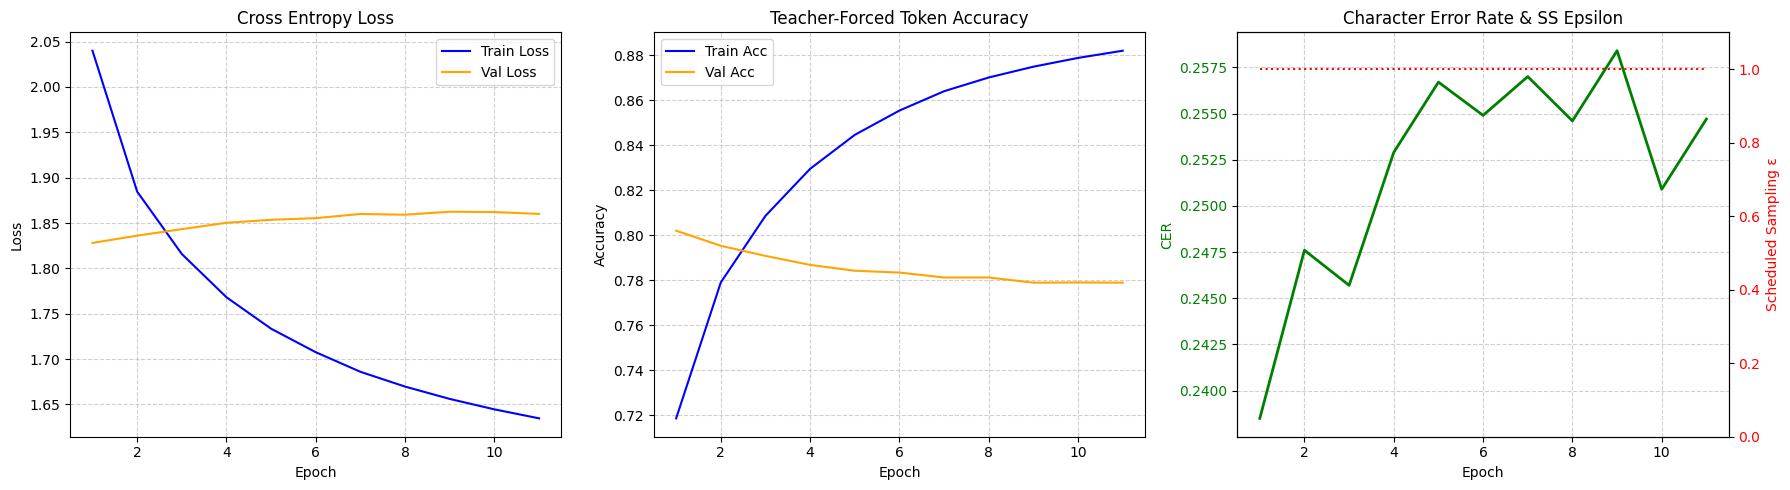

In [23]:
import matplotlib.pyplot as plt

# 1. Manually reconstruct the history dictionary from your printed logs
history = {
    'tr_loss': [2.0400, 1.8847, 1.8159, 1.7682, 1.7335, 1.7076, 1.6860, 1.6697, 1.6561, 1.6446, 1.6347],
    'tr_acc':  [0.7186, 0.7790, 0.8086, 0.8295, 0.8446, 0.8554, 0.8640, 0.8701, 0.8749, 0.8788, 0.8820],
    'vl_loss': [1.8281, 1.8361, 1.8433, 1.8503, 1.8536, 1.8554, 1.8600, 1.8592, 1.8625, 1.8621, 1.8601],
    'vl_acc':  [0.8020, 0.7953, 0.7908, 0.7868, 0.7842, 0.7834, 0.7812, 0.7812, 0.7789, 0.7790, 0.7789],
    'cer':     [0.2385, 0.2476, 0.2457, 0.2529, 0.2567, 0.2549, 0.2570, 0.2546, 0.2584, 0.2509, 0.2547],
    'epsilon': [1.0] * 11  # Epsilon was 1.0 for all epochs in the fast loop
}

# 2. Plot Training Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['tr_loss']) + 1)

# Loss Plot
axes[0].plot(epochs_range, history['tr_loss'], label='Train Loss', color='blue')
axes[0].plot(epochs_range, history['vl_loss'], label='Val Loss', color='orange')
axes[0].set_title('Cross Entropy Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.6)

# Accuracy Plot
axes[1].plot(epochs_range, history['tr_acc'], label='Train Acc', color='blue')
axes[1].plot(epochs_range, history['vl_acc'], label='Val Acc', color='orange')
axes[1].set_title('Teacher-Forced Token Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.6)

# CER & Epsilon Plot
ax3 = axes[2]
ax3.plot(epochs_range, history['cer'], label='Val CER (Beam)', color='green', linewidth=2)
ax3.set_title('Character Error Rate & SS Epsilon')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('CER', color='green')
ax3.tick_params(axis='y', labelcolor='green')
ax3.grid(True, linestyle='--', alpha=0.6)

ax3_twin = ax3.twinx()
ax3_twin.plot(epochs_range, history['epsilon'], label='SS Epsilon', color='red', linestyle=':')
ax3_twin.set_ylabel('Scheduled Sampling ε', color='red')
ax3_twin.tick_params(axis='y', labelcolor='red')
ax3_twin.set_ylim([0, 1.1]) # Lock the y-axis for epsilon so the flat line looks correct

plt.tight_layout()
plt.show()

## 13. Load Best Weights & Prepare Test Data

In [ ]:
# 1. Define the missing test dataset (My apologies for dropping this!)
test_ds = ProcessedNPYDataset(test_split_meta, Config.NPY_TRAIN, augment=False)

# 2. Load the best weights from the training loop
best_ckpt = torch.load(Config.CKPT_BEST, map_location=DEVICE, weights_only=True)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()
print(" Best validation checkpoint loaded for evaluation.")

# 3. Create the test dataloader
test_loader = make_loader(test_ds, shuffle=False)
print(f"Test Set Size: {len(test_ds):,} sequences")

✓ Best validation checkpoint loaded for evaluation.
Test Set Size: 10,144 sequences


## 14. Optional — Beam Width & Length Penalty Sweep

This runs a fast grid search over 200 validation samples to find the optimal decoding parameters before hitting the test set.

In [ ]:
@torch.no_grad()
def sweep_beam_params(model, dataset, n_samples=200):
    model.eval()
    beam_widths = [1, 3, 5]
    length_penalties = [0.6, 0.8, 1.0]
    
    results = {}
    print("Starting Beam Search Hyperparameter Sweep")
    
    for bw in beam_widths:
        for lp in length_penalties:
            cer_vals = []
            # Use a fixed subset for fair comparison
            for i in range(min(n_samples, len(dataset))):
                x, y = dataset[i]
                pred = beam_search(model, x, beam_width=bw, max_len=Config.MAX_PHRASE_LEN, length_penalty=lp)
                ps, ts = decode_seq(pred), decode_seq(y.numpy())
                if len(ts) > 0:
                    cer_vals.append(editdistance.eval(ps, ts) / len(ts))
            
            avg_cer = np.mean(cer_vals)
            results[(bw, lp)] = avg_cer
            print(f"Beam Width: {bw} | Length Penalty: {lp:.1f}  =>  CER: {avg_cer:.4f}")
            
    best_params = min(results, key=results.get)
    print(f"\n Best Params -> Beam Width: {best_params[0]}, Length Penalty: {best_params[1]} (CER: {results[best_params]:.4f})")
    return best_params

# Run sweep
best_bw, best_lp = sweep_beam_params(model, val_ds, n_samples=200)

# Update Config with best parameters found
Config.BEAM_WIDTH = best_bw
Config.LENGTH_PENALTY = best_lp

Starting Beam Search Hyperparameter Sweep...
Beam Width: 1 | Length Penalty: 0.6  =>  CER: 0.3613
Beam Width: 1 | Length Penalty: 0.8  =>  CER: 0.3613
Beam Width: 1 | Length Penalty: 1.0  =>  CER: 0.3613
Beam Width: 3 | Length Penalty: 0.6  =>  CER: 0.3294
Beam Width: 3 | Length Penalty: 0.8  =>  CER: 0.3338
Beam Width: 3 | Length Penalty: 1.0  =>  CER: 0.3439
Beam Width: 5 | Length Penalty: 0.6  =>  CER: 0.3269
Beam Width: 5 | Length Penalty: 0.8  =>  CER: 0.3339
Beam Width: 5 | Length Penalty: 1.0  =>  CER: 0.3506

🏆 Best Params -> Beam Width: 5, Length Penalty: 0.6 (CER: 0.3269)


## 15. Final Evaluation — Held-Out Test Set

In [ ]:
@torch.no_grad()
def evaluate_test_set(model, dataset, bw, lp):
    model.eval()
    cer_vals = []
    test_preds, test_tgts = [], []
    
    pbar = tqdm(range(len(dataset)), desc="Testing Model")
    for i in pbar:
        x, y = dataset[i]
        pred = beam_search(model, x, beam_width=bw, max_len=Config.MAX_PHRASE_LEN, length_penalty=lp)
        ps, ts = decode_seq(pred), decode_seq(y.numpy())
        
        test_preds.append(ps)
        test_tgts.append(ts)
        
        if len(ts) > 0:
            cer = editdistance.eval(ps, ts) / len(ts)
            cer_vals.append(cer)
            
        if (i + 1) % 50 == 0:
            pbar.set_postfix({'Test CER': f'{np.mean(cer_vals):.4f}'})
            
    return np.mean(cer_vals), test_preds, test_tgts

final_cer, preds, tgts = evaluate_test_set(model, test_ds, Config.BEAM_WIDTH, Config.LENGTH_PENALTY)

print(f"\n{'='*40}")
print(f"FINAL TEST CER: {final_cer:.4f}")
print(f"{'='*40}\n")

print("Sample Predictions:")
print(f"{'Match':<6} | {'Ground Truth':<30} | {'Prediction'}")
print("-" * 70)
for gt, pred in zip(tgts[:20], preds[:20]):
    match = 'YES' if gt == pred else 'NO'
    print(f"{match:<6} | {gt:<30} | {pred}")

Testing Model:   0%|          | 0/10144 [00:00<?, ?it/s]


FINAL TEST CER: 0.4299

Sample Predictions:
Match  | Ground Truth                   | Prediction
----------------------------------------------------------------------
✗      | scales/kuhaylah                | scales/kuhaya
✓      | 1383 william lanier            | 1383 william lanier
✗      | wildberries_ru                 | a will dewers
✗      | 1600 fire water                | 1600 the water
✗      | +45-39-007-1887                | +45-39-007-187
✗      | 596-033-4046                   | 510-518-4448
✗      | 6676 district 15 road          | the price is a very to road
✗      | tempemarketplace.com           | techemarketplace.com
✗      | 5270 brasher drive             | 570 northwest 15th street
✓      | webthesis.biblio.polito.it     | webthesis.biblio.polito.it
✗      | www.zobozdrav-vestn.si         | we to do you get
✗      | stars94.bg                     | stars94.by
✗      | 752-573-2075                   | 752-543-2070
✗      | +31-103-4764-61-76950          | +31-131-4

## 16. Save Final Checkpoint (Packaged for Deployment)

This builds a "fat" checkpoint dictionary containing everything needed to reconstruct the model without hardcoding hyperparameters in the inference scripts.

In [21]:
final_ckpt_path = Config.OUTPUT_DIR / 'asl_transformer_v6_final.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'char_to_idx':      char_to_idx,
    'idx_to_char':      idx_to_char,
    'feature_size':     Config.FEATURE_SIZE,
    'vocab_size':       VOCAB_SIZE,
    'n_classes':        N_CLASSES,
    'start_idx':        START_IDX,
    'eos_idx':          EOS_IDX,
    'pad_idx':          PAD_IDX,
    'max_seq_len':      Config.MAX_SEQ_LEN,
    'max_phrase_len':   Config.MAX_PHRASE_LEN,
    'd_model':          Config.D_MODEL,
    'enc_layers':       Config.ENC_LAYERS,
    'dec_layers':       Config.DEC_LAYERS,
    'n_heads':          Config.N_HEADS,
    'ffn_dim':          Config.FFN_DIM,
    'embed_dim':        Config.EMBED_DIM,
    'test_cer':         final_cer,
    'beam_width':       Config.BEAM_WIDTH,
    'length_penalty':   Config.LENGTH_PENALTY
}, final_ckpt_path)

print(f"Final model architecture, vocabulary, and weights successfully saved to:\n{final_ckpt_path}")

Final model architecture, vocabulary, and weights successfully saved to:
/kaggle/working/asl_transformer_v6_final.pth
